# Experiment Hub: Approximate Program Synthesis for Efficient ML

Central notebook for running all experiments, collecting data, and plotting results.

**Sections:**
1. Synthesis + Accuracy Pipeline
2. Hyperparameter Sweep
3. Grammar Selection Study
4. Ablation Study (CVC5 vs FloPoCo, Constraint Relaxation, Bitvector Sweep)
5. Cross-cutting Summary

In [1]:
import json
import os

# Ensure iverilog/vvp are on PATH (conda pkg cache on supervisor server)
os.environ["PATH"] = "/home/josephluke/.local/bin:/home/josephluke/.conda/pkgs/iverilog-11.0-hd56c0c9_0/bin:" + os.environ.get("PATH", "")
import re
import shutil
import subprocess
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "src" / "synthesis_driver.py").exists() and (root / "accuracy_tests" / "Makefile").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root")


ROOT = find_repo_root()
ACC_DIR = ROOT / "accuracy_tests"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.run_vitis_hls import parse_reports


# ────────────── Shared helpers ──────────────

def tail(text: str, lines: int = 200) -> str:
    parts = (text or "").splitlines()
    return "\n".join(parts[-lines:])


def extract_metrics(text: str) -> dict:
    """Parse cocotb test output for accuracy metrics (MXINT8 and FP32 formats)."""
    metrics: dict = {}
    for raw in (text or "").splitlines():
        line = raw.strip()
        # MXINT8 format: "Ran N test cases (skipped M)"
        m_ran = re.search(r"Ran\s+\d+\s+(?:test\s+)?cases?\s+\(skipped\s+\d+\)", line)
        if m_ran:
            metrics["ran"] = m_ran.group(0)
        if "Percent Within" in line:
            metrics.setdefault("percent_within", []).append(line)
        if "Max Absolute Error:" in line:
            metrics.setdefault("max_abs", []).append(line)
        if "Average Absolute Error:" in line:
            metrics.setdefault("avg_abs", []).append(line)
        if "99th Percentile" in line:
            metrics.setdefault("p99", []).append(line)
        if "95th Percentile" in line:
            metrics.setdefault("p95", []).append(line)
        # FP32 inline format: "[IN-DIST ...] ... Exact match: X%. Within Y% relative error: Z%"
        # or untagged: "Ran N cases (skipped M). Exact match: X%. Within Y% relative error: Z%"
        if "[IN-DIST" in line or "[GENERALISATION" in line:
            metrics.setdefault("fp32_inline", []).append(line)
            m_ran2 = re.search(r"Ran\s+\d+\s+cases\s+\(skipped\s+\d+\)", line)
            if m_ran2:
                metrics["ran"] = m_ran2.group(0)
        elif "Exact match:" in line and "Within" in line and "relative error" in line:
            metrics.setdefault("fp32_inline", []).append("[IN-DIST] " + line)
            m_ran2 = re.search(r"Ran\s+\d+\s+cases\s+\(skipped\s+\d+\)", line)
            if m_ran2:
                metrics["ran"] = m_ran2.group(0)
    return metrics


def parse_accuracy_rc_from_driver(text: str):
    if "[SUCCESS] Accuracy run completed successfully." in text:
        return 0
    m = re.search(r"Accuracy run failed with return code\s+(\d+)", text)
    return int(m.group(1)) if m else None


def _parse_ran(line):
    m = re.search(r"Ran\s+(\d+)\s+(?:test\s+)?cases?\s+\(skipped\s+(\d+)\)", line or "")
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)


def _parse_value_after_colon(line):
    m = re.search(r":\s*(-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", line or "")
    return float(m.group(1)) if m else np.nan


def _parse_percent_after_colon(line):
    m = re.search(r":\s*([0-9]+(?:\.[0-9]+)?)\s*%", line or "")
    return float(m.group(1)) if m else np.nan


def tol_tag(value: float) -> str:
    return str(value).replace(".", "p")


def parse_mode_tol(tag: str) -> tuple:
    m = re.match(r"^mode_(.+)__rel_([0-9p]+)$", tag)
    if not m:
        return ("unknown", float("nan"))
    return (m.group(1), float(m.group(2).replace("p", ".")))


print(f"Repo root: {ROOT}")
print("Setup complete.")

Repo root: /home/josephluke/Program-Synthesis-for-Efficient-ML
Setup complete.


# 1. Synthesis + Accuracy Pipeline

Runs SMT synthesis, hardware synthesis (Vitis HLS + Vivado), and cocotb accuracy tests for all targets.
Covers `FP32` and `MXINT8` addition/multiplication — both `subcomponent` and `combined` variants, plus FloPoCo baselines.

In [ ]:
# ──────── Load Pipeline Results from HLS Output Directories ────────
# Scans results/HLS/solution_* for Vivado reports (post-impl) and
# results/{c,cpp}/ for solution files. Accuracy is parsed from pipeline logs.

PIPELINE_TARGETS = [
    {"name": "mxint8_add_subcomponents", "op": "Addition",       "dtype": "MXINT8", "variant": "Subcomponents", "soln": "solution_mxint8addition_full_sum",               "top": "add_full_sum",            "base": "HLS"},
    {"name": "mxint8_add_v1",            "op": "Addition",       "dtype": "MXINT8", "variant": "V1",            "soln": "solution_mxint8addition_full_sum_v1",             "top": "add_full_sum",            "base": "HLS"},
    {"name": "mxint8_add_v2",            "op": "Addition",       "dtype": "MXINT8", "variant": "V2",            "soln": "solution_mxint8addition_full_sum_v2",             "top": "add_full_sum",            "base": "HLS"},
    {"name": "mxint8_mul_subcomponents", "op": "Multiplication", "dtype": "MXINT8", "variant": "Subcomponents", "soln": "solution_mxint8multiplication_full_product",      "top": "mult_mxint_full_product", "base": "HLS"},
    {"name": "mxint8_mul_v1",            "op": "Multiplication", "dtype": "MXINT8", "variant": "V1",            "soln": "solution_mxint8multiplication_full_product_v1",   "top": "mult_mxint_full_product", "base": "HLS"},
    {"name": "mxint8_mul_v2",            "op": "Multiplication", "dtype": "MXINT8", "variant": "V2",            "soln": "solution_mxint8multiplication_full_product_v2",   "top": "mult_mxint_full_product", "base": "HLS"},
    {"name": "fp32_add_subcomponents",   "op": "Addition",       "dtype": "FP32",   "variant": "Subcomponents", "soln": "solution_fp32addition_full_sum",                  "top": "fp32_sum",                "base": "HLS"},
    {"name": "fp32_add_v1",              "op": "Addition",       "dtype": "FP32",   "variant": "V1",            "soln": "solution_fp32addition_full_sum_v1",               "top": "fp32_sum",                "base": "HLS"},
    {"name": "fp32_add_v2",              "op": "Addition",       "dtype": "FP32",   "variant": "V2",            "soln": "solution_fp32addition_full_sum_v2",               "top": "fp32_sum",                "base": "HLS"},
    {"name": "fp32_mul_subcomponents",   "op": "Multiplication", "dtype": "FP32",   "variant": "Subcomponents", "soln": "solution_fp32multiplication_full_product",        "top": "fp32_full_mul",           "base": "HLS"},
    {"name": "fp32_mul_v1",              "op": "Multiplication", "dtype": "FP32",   "variant": "V1",            "soln": "solution_fp32multiplication_full_product_v1",     "top": "fp32_full_mul",           "base": "HLS"},
    {"name": "fp32_mul_v2",              "op": "Multiplication", "dtype": "FP32",   "variant": "V2",            "soln": "solution_fp32multiplication_full_product_v2",     "top": "fp32_full_mul",           "base": "HLS"},
    {"name": "fp32_add_flopoco",         "op": "Addition",       "dtype": "FP32",   "variant": "FloPoCo",       "soln": "solution_fp32addition_flopoco",                   "top": "fp32_sum_flopoco",        "base": "FLOPOCO"},
    {"name": "fp32_mul_flopoco",         "op": "Multiplication", "dtype": "FP32",   "variant": "FloPoCo",       "soln": "solution_fp32multiplication_flopoco",             "top": "fp32_full_mul_flopoco",   "base": "FLOPOCO"},
]

# ── Build hardware DataFrame by parsing Vivado reports ──
hw_rows = []
for t in PIPELINE_TARGETS:
    out_dir = ROOT / "results" / t["base"] / t["soln"]
    row = {**t, "exists": out_dir.exists()}
    if out_dir.exists():
        hw = parse_reports(out_dir, t["top"], t["soln"], run_impl=True)
        row.update(hw)
    else:
        for c in ["LUTs", "FFs", "DSPs", "BRAMs", "Cycles", "Fmax_MHz", "Latency_ns"]:
            row[c] = np.nan
    hw_rows.append(row)

hw_df = pd.DataFrame(hw_rows)

# ── Parse accuracy from pipeline logs (one per component) ──
acc_rows = []
for t in PIPELINE_TARGETS:
    log_candidates = sorted(
        (ROOT / "logs").glob(f"pipeline_{t['name'].split('_')[0]}_{t['name'].split('_')[1]}*.log"),
        key=lambda p: p.stat().st_mtime, reverse=True
    )
    metrics = {}
    acc_rc = None
    for lf in log_candidates:
        text = lf.read_text()
        # Find section for this specific solution
        sec_match = re.search(rf'HLS_SOLN={re.escape(t["soln"])}.*?(?=HLS_SOLN=|\Z)', text, re.DOTALL)
        if sec_match:
            sec = sec_match.group(0)
            metrics = extract_metrics(sec)
            acc_rc = parse_accuracy_rc_from_driver(sec)
            break
        # Also try the full log if solution-specific section not found
        if not metrics:
            metrics = extract_metrics(text)
            acc_rc = parse_accuracy_rc_from_driver(text)

    m = metrics
    tested, skipped = _parse_ran(m.get("ran"))
    row = {
        "name": t["name"], "op": t["op"], "dtype": t["dtype"], "variant": t["variant"],
        "status": "SKIP" if acc_rc is None else ("PASS" if acc_rc == 0 else "FAIL"),
        "tested": tested, "skipped": skipped,
    }
    # MXINT8 metrics
    for prefix, idx in [("quant", 0), ("full", 1)]:
        for key, parser in [("max_abs", _parse_value_after_colon),
                            ("avg_abs", _parse_value_after_colon),
                            ("p99", _parse_value_after_colon)]:
            vals = m.get(key, [])
            row[f"{prefix}_{key}"] = parser(vals[idx]) if len(vals) > idx else np.nan
        pctw = m.get("percent_within", [])
        row[f"{prefix}_pct_within_fs"] = _parse_percent_after_colon(pctw[idx]) if len(pctw) > idx else np.nan

    # FP32 inline metrics
    for fp_line in m.get("fp32_inline", []):
        m_exact = re.search(r"Exact match:\s*([\d.]+)%", fp_line)
        m_within = re.search(r"Within\s+\d+%\s+relative error:\s*([\d.]+)%", fp_line)
        if "[IN-DIST" in fp_line:
            if m_exact: row["fp32_indist_exact"] = float(m_exact.group(1))
            if m_within: row["fp32_indist_within_rel"] = float(m_within.group(1))
        elif "[GENERALISATION" in fp_line:
            if m_exact: row["fp32_gen_exact"] = float(m_exact.group(1))
            if m_within: row["fp32_gen_within_rel"] = float(m_within.group(1))
    acc_rows.append(row)

acc_df = pd.DataFrame(acc_rows)

# ── Merge hardware + accuracy ──
merged = hw_df.merge(acc_df.drop(columns=["name"], errors="ignore"),
                     on=["op", "dtype", "variant"], how="left")
for col in ["Fmax_MHz", "LUTs", "FFs", "DSPs", "BRAMs", "Cycles", "Latency_ns"]:
    if col in merged.columns:
        merged[col] = merged[col].replace(-1, np.nan)

# Unified accuracy column: MXINT8 uses quant_pct_within_fs, FP32 uses fp32_indist_within_rel
_fp32_within = merged.get("fp32_indist_within_rel", np.nan)
merged["within5pct"] = np.where(merged["dtype"] == "MXINT8", merged["quant_pct_within_fs"], _fp32_within)

# ADP = LUT_equiv * Latency_ns
merged["LUT_equiv"] = merged["LUTs"].fillna(0) + merged["DSPs"].fillna(0) * 150
merged["ADP"] = merged["LUT_equiv"] * merged["Latency_ns"]

# ── Display summary table ──
display_cols = [c for c in ["op", "dtype", "variant", "status", "LUTs", "FFs", "DSPs",
                             "Fmax_MHz", "Latency_ns", "ADP", "within5pct",
                             "fp32_indist_exact", "fp32_indist_within_rel"] if c in merged.columns]
view = merged[display_cols].sort_values(["op", "dtype", "variant"]).reset_index(drop=True)
n_found = merged["exists"].sum()
print(f"Pipeline results: {n_found}/{len(PIPELINE_TARGETS)} HLS directories found")
print("Unified hardware + accuracy summary")
display(view)

In [ ]:
# ──────── Pipeline Hardware Comparison: LUTs, Latency, ADP ────────
VARIANT_ORDER = ["Subcomponents", "V1", "V2", "FloPoCo"]
VARIANT_COLORS = {"Subcomponents": "#4CAF50", "V1": "#FF9800", "V2": "#9C27B0", "FloPoCo": "#607D8B"}

cvc5_only = merged[merged["variant"] != "FloPoCo"].copy()

# ── Bar charts: LUTs, Latency, ADP by component × grammar ──
for metric, title, fmt in [("LUTs", "LUTs (Post-Implementation)", ".0f"),
                            ("Latency_ns", "Latency (ns)", ".2f"),
                            ("ADP", "Area-Delay Product (LUT·ns)", ".0f")]:
    if metric not in cvc5_only.columns or cvc5_only[metric].isna().all():
        continue
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    for ax, op in zip(axes, ["Addition", "Multiplication"]):
        d = cvc5_only[cvc5_only["op"] == op].copy()
        d["variant"] = pd.Categorical(d["variant"], categories=VARIANT_ORDER, ordered=True)
        pivot = d.pivot(index="dtype", columns="variant", values=metric).reindex(["MXINT8", "FP32"])
        pivot = pivot.reindex(columns=[v for v in VARIANT_ORDER if v in pivot.columns])
        pivot.plot(kind="bar", ax=ax, rot=0, color=[VARIANT_COLORS[v] for v in pivot.columns],
                   edgecolor="white", width=0.7)
        ax.set_title(op, fontsize=11)
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=8)
        # Value annotations
        for container in ax.containers:
            ax.bar_label(container, fmt=f"%{fmt}", fontsize=7, padding=2)
    fig.suptitle(f"{title}: Grammar Comparison (CVC5 Synthesised)", fontsize=13)
    plt.show()

# ── Accuracy vs Area scatter (per operation, all variants incl. FloPoCo) ──
plot_df = merged.dropna(subset=["LUTs", "within5pct"]).copy()
markers = {"Subcomponents": "o", "V1": "^", "V2": "s", "FloPoCo": "D"}
dtype_colors = {"MXINT8": "#2196F3", "FP32": "#FF5722"}

if not plot_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)
    for ax, op in zip(axes, ["Addition", "Multiplication"]):
        d = plot_df[plot_df["op"] == op]
        for _, row in d.iterrows():
            ax.scatter(row["LUT_equiv"], row["within5pct"],
                       marker=markers.get(row["variant"], "x"),
                       color=dtype_colors.get(row["dtype"], "gray"),
                       s=100, edgecolors="black", linewidth=0.6, zorder=5,
                       label=f"{row['dtype']} {row['variant']}")
        ax.set_xlabel("Area (LUTs + DSPs x 150)")
        ax.set_title(op, fontsize=11)
        ax.set_ylim(-2, 108)
        ax.grid(alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=7, loc="lower right")
    axes[0].set_ylabel("Within-5% Accuracy (%)")
    fig.suptitle("Accuracy vs Area (All Variants)", fontsize=13)
    plt.show()

# 2. Hyperparameter Sweep

Sweeps solver `timeout` and `num_iterations` to find the optimal balance for each synthesis target.
Supports 1D sweeps (`timeout-sweep`, `iter-sweep`) and 2D joint grid (`joint`).
Uses `--patience` for early stopping when metrics plateau.

In [ ]:
# ──────── Hyperparameter Sweep Analysis ────────
HP_OUTPUT_DIR = "results/hyperparameter_sweep/fine_v4"

from collections import defaultdict as _dd

_hp_root = ROOT / "results" / "hyperparameter_sweep"

# Collect candidates: level-1 (single-dir) and level-2 (parallel-per-benchmark)
_level1 = list(_hp_root.glob("*/runs.jsonl"))
_level2 = list(_hp_root.glob("*/*/runs.jsonl"))

_level2_groups = _dd(list)
for _p in _level2:
    _level2_groups[_p.parent.parent].append(_p)

_candidates = []
for _p in _level1:
    _candidates.append((_p.stat().st_mtime, _p.parent.name, [_p]))
for _parent, _files in _level2_groups.items():
    _mtime = max(_p.stat().st_mtime for _p in _files)
    _candidates.append((_mtime, _parent.name, sorted(_files)))
_candidates.sort(key=lambda x: x[0], reverse=True)

# Explicit override takes priority
if "HP_OUTPUT_DIR" in dir():
    _override_dir = ROOT / HP_OUTPUT_DIR
    _override_single = _override_dir / "runs.jsonl"
    _override_multi = list(_override_dir.glob("*/runs.jsonl"))
    if _override_single.exists():
        _candidates.insert(0, (_override_single.stat().st_mtime, HP_OUTPUT_DIR, [_override_single]))
    elif _override_multi:
        _mtime = max(p.stat().st_mtime for p in _override_multi)
        _candidates.insert(0, (_mtime, HP_OUTPUT_DIR, sorted(_override_multi)))

if not _candidates:
    raise FileNotFoundError("No hyperparameter sweep results found.")

_best_mtime, _best_label, hp_files = _candidates[0]
hp_dir = hp_files[0].parent if len(hp_files) == 1 else hp_files[0].parent.parent

hp_rows = []
for _f in hp_files:
    for _line in _f.read_text().strip().split("\n"):
        if _line.strip():
            hp_rows.append(json.loads(_line))

print(f"Loaded {len(hp_rows)} runs from '{_best_label}' ({len(hp_files)} file(s))")
if len(hp_files) > 1:
    _counts = _dd(int)
    for _r in hp_rows:
        _counts[_r['benchmark']] += 1
    print("  Benchmarks loaded:", dict(_counts))

hp_df = pd.DataFrame(hp_rows)

has_accuracy = "within_rel_pct" in hp_df.columns and hp_df["within_rel_pct"].notna().any()
has_luts     = "luts" in hp_df.columns and hp_df["luts"].notna().any()
has_fmax     = "fmax_mhz" in hp_df.columns and hp_df["fmax_mhz"].notna().any()
has_adp      = "adp_lut_ns" in hp_df.columns and hp_df["adp_lut_ns"].notna().any()
print(f"  Accuracy: {has_accuracy}   LUTs: {has_luts}   Fmax: {has_fmax}   ADP: {has_adp}")

SOLVE_RATE_THRESH = 1/3

# ── Aggregate per (benchmark, timeout, iterations) ──
agg_rows = []
for bench in hp_df["benchmark"].unique():
    bdf = hp_df[hp_df["benchmark"] == bench]
    for (t, i), gdf in bdf.groupby(["timeout", "num_iterations"]):
        within = gdf["within_rel_pct"].dropna().tolist() if has_accuracy else []
        luts   = gdf["luts"].dropna().tolist()           if has_luts     else []
        adp    = gdf["adp_lut_ns"].dropna().tolist()     if has_adp      else []
        agg_rows.append({
            "benchmark": bench, "timeout": int(t), "num_iterations": int(i),
            "solve_rate":        gdf["solution_found"].mean(),
            "mean_accepted":     gdf["accepted_constraints"].mean(),
            "mean_wall":         gdf["wall_seconds"].mean(),
            "mean_within_rel_pct": float(np.mean(within)) if within else np.nan,
            "mean_luts":         float(np.mean(luts))     if luts   else np.nan,
            "mean_fmax_mhz":     float(np.mean(gdf["fmax_mhz"].dropna().tolist())) if has_fmax and gdf["fmax_mhz"].dropna().size > 0 else np.nan,
            "mean_latency_ns":   float(np.mean(gdf["latency_ns"].dropna().tolist())) if has_fmax and gdf["latency_ns"].dropna().size > 0 else np.nan,
            "mean_adp":          float(np.mean(adp)) if adp else np.nan,
        })
agg = pd.DataFrame(agg_rows)

# ── Best parameters per benchmark ──
best_rows = []
for bench in agg["benchmark"].unique():
    bdf = agg[agg["benchmark"] == bench]
    eligible = bdf[bdf["solve_rate"] >= SOLVE_RATE_THRESH]
    if eligible.empty:
        eligible = bdf
    if has_adp and eligible["mean_adp"].notna().any():
        best = eligible.loc[eligible["mean_adp"].idxmin()]
        ranked_by = "mean_adp"
    elif has_accuracy and eligible["mean_within_rel_pct"].notna().any():
        best = eligible.loc[eligible["mean_within_rel_pct"].idxmax()]
        ranked_by = "mean_within_rel_pct"
    else:
        best = eligible.loc[eligible["mean_accepted"].idxmax()]
        ranked_by = "mean_accepted"
    best_rows.append({
        "Benchmark": bench,
        "Best Timeout (s)":   int(best["timeout"]),
        "Best Iterations":    int(best["num_iterations"]),
        "Solve Rate":         f"{best['solve_rate']:.0%}",
        "Mean ADP (LUT-ns)":  f"{best['mean_adp']:.1f}" if not np.isnan(best.get("mean_adp", np.nan)) else "N/A",
        "Mean Accuracy (5%)": f"{best['mean_within_rel_pct']*100:.1f}%" if not np.isnan(best.get("mean_within_rel_pct", np.nan)) else "N/A",
        "Ranked By": ranked_by,
    })
print(f"\nBest hyperparameters per benchmark (solve-rate >= {SOLVE_RATE_THRESH:.0%})")
display(pd.DataFrame(best_rows))

# ── Heatmap helper ──
benchmarks = sorted(hp_df["benchmark"].unique())
n_bench = len(benchmarks)
ncols = min(n_bench, 4)
nrows = (n_bench + ncols - 1) // ncols

def _heatmap(ax, bench, col, label, cmap, vmin=None, vmax=None, scale=1.0, fmt=".1f", agg_df=None):
    src = agg_df if agg_df is not None else hp_df
    if agg_df is not None:
        pivot = src[src["benchmark"] == bench].pivot_table(index="timeout", columns="num_iterations", values=col)
    else:
        pivot = src[src["benchmark"] == bench].pivot_table(index="timeout", columns="num_iterations", values=col, aggfunc="mean")
    vals = pivot.values * scale
    im = ax.imshow(vals, aspect="auto", cmap=cmap, origin="lower", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns.astype(int), fontsize=8)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index.astype(int),   fontsize=8)
    ax.set_xlabel("Iterations"); ax.set_ylabel("Timeout (s)")
    ax.set_title(bench.replace("_", " ").title(), fontsize=10)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if not np.isnan(v):
                normed = (v - np.nanmin(vals)) / (np.nanmax(vals) - np.nanmin(vals) + 1e-9)
                color = "white" if normed < 0.3 or normed > 0.7 else "black"
                ax.text(j, i, format(v, fmt), ha="center", va="center", fontsize=7, color=color)
    plt.colorbar(im, ax=ax, shrink=0.8, label=label)

# ── ADP heatmap ──
if has_adp:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        ax = axes[idx//ncols][idx%ncols]
        _heatmap(ax, bench, "mean_adp", "ADP (LUT-ns)", "RdYlGn_r", agg_df=agg, fmt=".0f")
        bdf = agg[agg["benchmark"] == bench]
        eligible = bdf[bdf["solve_rate"] >= SOLVE_RATE_THRESH]
        if eligible.empty: eligible = bdf
        if eligible["mean_adp"].notna().any():
            best_row = eligible.loc[eligible["mean_adp"].idxmin()]
            pivot = bdf.pivot_table(index="timeout", columns="num_iterations", values="mean_adp")
            if best_row["timeout"] in pivot.index and best_row["num_iterations"] in pivot.columns:
                ti = list(pivot.index).index(best_row["timeout"])
                ii = list(pivot.columns).index(best_row["num_iterations"])
                ax.add_patch(plt.Rectangle((ii-0.5, ti-0.5), 1, 1, fill=False, edgecolor="blue", linewidth=2.5))
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("ADP (LUT-ns): Mean per Config  (blue = best)", fontsize=14)
    plt.show()

# ── Accuracy heatmap ──
if has_accuracy:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        _heatmap(axes[idx//ncols][idx%ncols], bench, "within_rel_pct", "Within 5% (%)", "RdYlGn", 0, 1, 100, ".0f")
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("Accuracy: Mean Within-5% per Config", fontsize=14); plt.show()

# ── Solve rate heatmap ──
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
for idx, bench in enumerate(benchmarks):
    _heatmap(axes[idx//ncols][idx%ncols], bench, "solution_found", "Solve Rate", "RdYlGn", 0, 1, 100, ".0f")
for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
fig.suptitle("Solve Rate per Config", fontsize=14); plt.show()

# ── Pareto scatter: accuracy vs ADP ──
if has_accuracy and has_adp:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True, squeeze=False)
    for idx, bench in enumerate(benchmarks):
        ax = axes[idx//ncols][idx%ncols]
        bagg = agg[agg["benchmark"] == bench].dropna(subset=["mean_within_rel_pct", "mean_adp"])
        sc = ax.scatter(bagg["mean_adp"], bagg["mean_within_rel_pct"]*100,
                        c=bagg["timeout"], cmap="coolwarm", s=70, edgecolors="black", linewidth=0.4, zorder=5)
        ax.set_xlabel("Mean ADP (LUT-ns)"); ax.set_ylabel("Mean Accuracy (%)")
        ax.set_ylim(-2, 105)
        ax.set_title(bench.replace("_", " ").title(), fontsize=10)
        ax.grid(alpha=0.3)
        plt.colorbar(sc, ax=ax, shrink=0.7, label="timeout (s)")
    for idx in range(n_bench, nrows*ncols): axes[idx//ncols][idx%ncols].set_visible(False)
    fig.suptitle("ADP vs Accuracy per Config (colour = timeout)", fontsize=14)
    plt.show()

# 3. Grammar Comparison

Subcomponents vs V1 (broad monolithic) vs V2 (tight structural sketch).
Compares synthesis speed, hardware cost, and accuracy — derived from pipeline results (Section 1).

In [ ]:
# ──────── Grammar Comparison: Subcomponents vs V1 vs V2 ────────
# Prefer the dedicated grammar_selection study (includes grammar metrics like
# search space, production counts, enumeration stats, runtimes across reps).
# Falls back to pipeline `merged` DataFrame if grammar_selection not available.

if "merged" not in globals():
    raise RuntimeError("Run Section 1 first to populate merged dataframe.")

GS_DIR = ROOT / "results" / "grammar_selection"
gs_jsonl = GS_DIR / "runs.jsonl"

label_map = {
    "mxint8_add": "MXINT8 Addition", "mxint8_mul": "MXINT8 Multiplication",
    "fp32_add": "FP32 Addition", "fp32_mul": "FP32 Multiplication",
}

USE_GS = gs_jsonl.exists()

if USE_GS:
    # ── Load grammar selection study data ────────────────────────────────────
    gs_runs = [json.loads(line) for line in gs_jsonl.read_text().strip().split("\n")]
    gs_df = pd.DataFrame(gs_runs)

    for col in ["LUTs", "FFs", "Fmax_MHz", "Latency_ns", "accuracy_exact_match", "within_rel_pct",
                "solver_runtime_seconds_total", "enum_count_primary_total",
                "accepted_constraints", "total_constraints",
                "abs_err_avg", "abs_err_max", "abs_err_p99"]:
        if col in gs_df.columns:
            gs_df[col] = pd.to_numeric(gs_df[col], errors="coerce")
            gs_df.loc[gs_df[col] < 0, col] = np.nan

    gs_df["label"] = gs_df["benchmark"].map(label_map).fillna(gs_df["benchmark"])
    gs_df["LUT_equiv"] = gs_df["LUTs"].fillna(0) + gs_df.get("DSPs", pd.Series(0)).fillna(0) * 150
    gs_df["ADP"] = gs_df["LUT_equiv"] * gs_df["Latency_ns"]

    # Build summary (mean across repetitions)
    gs_summary_path = GS_DIR / "summary.json"
    if gs_summary_path.exists():
        gs_sdf = pd.DataFrame(json.loads(gs_summary_path.read_text()))
        gs_sdf["label"] = gs_sdf["benchmark"].map(label_map).fillna(gs_sdf["benchmark"])
    else:
        # Build summary manually from per-run data
        group_cols = ["benchmark", "grammar_version"]
        num_cols = [c for c in gs_df.select_dtypes(include="number").columns if c not in group_cols]
        gs_sdf = gs_df.groupby(group_cols)[num_cols].mean().reset_index()
        gs_sdf["label"] = gs_sdf["benchmark"].map(label_map).fillna(gs_sdf["benchmark"])

    print(f"Grammar selection study: {len(gs_df)} runs loaded from {gs_jsonl}")
    versions_found = sorted(gs_df["grammar_version"].unique())
    print(f"Versions: {versions_found}")

    # ──── Table 1: Aggregate summary ────
    summary_cols = {
        "label": "Benchmark", "grammar_version": "Grammar", "num_subcomponents": "# Grammars",
        "mean_runtime_seconds": "Mean Runtime (s)",
        "mean_enum_count": "Mean Enum Terms", "mean_LUTs": "Mean LUTs",
        "mean_Fmax_MHz": "Mean Fmax (MHz)",
        "mean_Latency_ns": "Mean Latency (ns)",
        "mean_within_rel_pct": "Within Rel %",
        "total_productions": "Grammar Productions", "branching_nonterminals": "Branching NTs",
    }
    available = {k: v for k, v in summary_cols.items() if k in gs_sdf.columns}
    tbl = gs_sdf[list(available.keys())].rename(columns=available).copy()
    if "Mean Runtime (s)" in tbl.columns:
        tbl["Mean Runtime (s)"] = tbl["Mean Runtime (s)"].map(lambda x: f"{x:,.1f}" if pd.notna(x) else "\u2014")
    if "Mean Enum Terms" in tbl.columns:
        tbl["Mean Enum Terms"] = tbl["Mean Enum Terms"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "\u2014")
    if "Within Rel %" in tbl.columns:
        tbl["Within Rel %"] = tbl["Within Rel %"].map(lambda x: f"{x*100:.1f}%" if pd.notna(x) and x <= 1.0 else (f"{x:.1f}%" if pd.notna(x) else "\u2014"))
    tbl = tbl.sort_values(["Benchmark", "Grammar"]).reset_index(drop=True)

    print("\nGrammar Comparison: Subcomponents vs V1 (Broad) vs V2 (Tight Sketch)")
    print("=" * 90)
    display(tbl)

    # LaTeX export
    print("\nLaTeX table:\n")
    print(tbl.to_latex(index=False, escape=True))

    # ──── Per-run detail ────
    detail_cols = ["label", "grammar_version", "num_subcomponents", "repetition",
                   "accepted_constraints", "total_constraints",
                   "solver_runtime_seconds_total", "enum_count_primary_total",
                   "LUTs", "Fmax_MHz", "Latency_ns", "within_rel_pct"]
    detail_cols = [c for c in detail_cols if c in gs_df.columns]
    detail = gs_df[detail_cols].sort_values(["label", "grammar_version", "repetition"]).reset_index(drop=True)
    detail.columns = [c.replace("_", " ").title() for c in detail.columns]
    print("\nPer-run detail")
    display(detail)

    # ──── Charts: Grouped bar comparison ────
    benchmarks = sorted(gs_df["label"].unique())
    versions = ["Subcomponents", "V1", "V2"]
    colours = {"Subcomponents": "#009E73", "V1": "#E69F00", "V2": "#0072B2"}

    chart_specs = [
        ("solver_runtime_seconds_total", "Solver Runtime (s)", True),
        ("enum_count_primary_total", "Enumerated Terms", True),
        ("LUTs", "LUTs (Post-Implementation)", False),
        ("Latency_ns", "Latency (ns)", False),
    ]
    active_specs = [(col, title, use_log) for col, title, use_log in chart_specs
                    if col in gs_df.columns and gs_df[col].notna().any()]

    n_charts = len(active_specs)
    if n_charts > 0:
        n_cols = min(n_charts, 2)
        n_rows = (n_charts + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), constrained_layout=True)
        axes_flat = np.array(axes).flatten() if n_charts > 1 else [axes]

        for ax_idx, (col, title, use_log) in enumerate(active_specs):
            ax = axes_flat[ax_idx]
            x = np.arange(len(benchmarks))
            width = 0.22
            for i, ver in enumerate(versions):
                subset = gs_df[gs_df["grammar_version"] == ver]
                means = [subset[subset["label"] == b][col].mean() for b in benchmarks]
                stds  = [subset[subset["label"] == b][col].std()  for b in benchmarks]
                bar_h = [m if pd.notna(m) else 0 for m in means]
                bar_e = [s if pd.notna(s) else 0 for s in stds]
                offset = (i - 1) * width
                ax.bar(x + offset, bar_h, width, yerr=bar_e, label=ver,
                       color=colours[ver], capsize=3, edgecolor="white", linewidth=0.5)
            ax.set_xticks(x)
            ax.set_xticklabels(benchmarks, fontsize=9, rotation=15, ha="right")
            ax.set_title(title, fontsize=11)
            ax.legend(fontsize=9)
            ax.grid(axis="y", alpha=0.3)
            if use_log:
                ax.set_yscale("log")

        for ax_idx in range(len(active_specs), len(axes_flat)):
            axes_flat[ax_idx].set_visible(False)
        fig.suptitle("Grammar Comparison (from Grammar Selection Study)", fontsize=13, fontweight="bold")
        plt.show()

    # ──── Cross-version comparison table ────
    ratio_rows = []
    for bench in benchmarks:
        def _mean(ver, col):
            return gs_df[(gs_df["label"] == bench) & (gs_df["grammar_version"] == ver)][col].mean()
        rt1, rt2, rts = _mean("V1", "solver_runtime_seconds_total"), _mean("V2", "solver_runtime_seconds_total"), _mean("Subcomponents", "solver_runtime_seconds_total")
        en1, en2, ens = _mean("V1", "enum_count_primary_total"), _mean("V2", "enum_count_primary_total"), _mean("Subcomponents", "enum_count_primary_total")
        ratio_rows.append({
            "Benchmark": bench,
            "V1 Runtime (s)":    f"{rt1:,.1f}" if pd.notna(rt1) else "\u2014",
            "V2 Runtime (s)":    f"{rt2:,.1f}" if pd.notna(rt2) else "\u2014",
            "Sub Runtime (s)":   f"{rts:,.1f}" if pd.notna(rts) else "\u2014",
            "V2 Speedup vs V1":  f"{rt1/rt2:,.1f}x" if pd.notna(rt1) and pd.notna(rt2) and rt2 > 0 else "\u2014",
            "Sub Speedup vs V1": f"{rt1/rts:,.1f}x" if pd.notna(rt1) and pd.notna(rts) and rts > 0 else "\u2014",
        })
    if ratio_rows:
        print("\nCross-version runtime comparison")
        display(pd.DataFrame(ratio_rows))

else:
    # ── Fallback: derive from pipeline merged DataFrame ──────────────────────
    print("Grammar selection study not found — using pipeline results for grammar comparison.")
    gc = merged[merged["variant"].isin(["Subcomponents", "V1", "V2"])].copy()
    gc["label"] = gc.apply(lambda r: label_map.get(
        f"{'mxint8' if r['dtype']=='MXINT8' else 'fp32'}_{'add' if r['op']=='Addition' else 'mul'}",
        f"{r['dtype']} {r['op']}"), axis=1)

    summary_cols = {
        "label": "Benchmark", "variant": "Grammar",
        "LUTs": "LUTs", "FFs": "FFs", "DSPs": "DSPs",
        "Fmax_MHz": "Fmax (MHz)", "Latency_ns": "Latency (ns)",
        "ADP": "ADP (LUT·ns)", "within5pct": "Accuracy (%)",
    }
    available = {k: v for k, v in summary_cols.items() if k in gc.columns}
    tbl = gc[list(available.keys())].rename(columns=available).copy()
    for col, fmt in [("LUTs", ".0f"), ("FFs", ".0f"), ("DSPs", ".0f"),
                     ("Fmax (MHz)", ".1f"), ("Latency (ns)", ".2f"),
                     ("ADP (LUT·ns)", ".0f"), ("Accuracy (%)", ".1f")]:
        if col in tbl.columns:
            tbl[col] = tbl[col].apply(lambda x: f"{x:{fmt}}" if pd.notna(x) else "\u2014")
    tbl = tbl.sort_values(["Benchmark", "Grammar"]).reset_index(drop=True)
    print("\nGrammar Comparison (from pipeline results — no per-rep stats):")
    print("=" * 90)
    display(tbl)

    # Bar charts from pipeline data
    benchmarks = sorted(gc["label"].unique())
    versions = ["Subcomponents", "V1", "V2"]
    colours = {"Subcomponents": "#009E73", "V1": "#E69F00", "V2": "#0072B2"}
    for metric, title in [("LUTs", "LUTs"), ("Latency_ns", "Latency (ns)"), ("ADP", "ADP (LUT·ns)")]:
        if metric not in gc.columns or gc[metric].isna().all():
            continue
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(benchmarks))
        width = 0.22
        for i, ver in enumerate(versions):
            subset = gc[gc["variant"] == ver]
            vals = [subset[subset["label"] == b][metric].values for b in benchmarks]
            means = [v[0] if len(v) > 0 and pd.notna(v[0]) else 0 for v in vals]
            offset = (i - 1) * width
            bars = ax.bar(x + offset, means, width, label=ver,
                          color=colours[ver], edgecolor="white", linewidth=0.5)
            ax.bar_label(bars, fmt="%.0f", fontsize=7, padding=2)
        ax.set_xticks(x)
        ax.set_xticklabels(benchmarks, fontsize=9, rotation=15, ha="right")
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

# 4. Ablation Study

Factorial ablation measuring the contribution of each technique:
- **CVC5**: Our synthesiser's output vs FloPoCo's human-designed hardware
- **Relaxation**: Staged MSB constraint relaxation — applies to **monolithic grammars (V1, V2) only**
- **BV Search**: Bitvector width optimisation (mantissa truncation) — applies to **subcomponent grammar only**

> **Note:** Relaxation and BV Search are mutually exclusive — they apply to different grammar
> approaches. Relaxation operates during synthesis for monolithic solutions; BV Search
> post-processes the decomposed subcomponent solution.

| Config | Source | Grammar | Relaxation | BV Search |
|--------|--------|---------|------------|-----------|
| FloPoCo baseline | FloPoCo | — | — | — |
| FloPoCo + BV | FloPoCo | — | — | ✓ |
| CVC5 (Subcomponents) | CVC5 | Subcomponents | — | — |
| CVC5 (Subcomponents) + BV | CVC5 | Subcomponents | — | ✓ |
| CVC5 (V1) | CVC5 | V1 (monolithic) | — | — |
| CVC5 (V1) + Relaxation | CVC5 | V1 (monolithic) | ✓ | — |
| CVC5 (V2) | CVC5 | V2 (monolithic) | — | — |
| CVC5 (V2) + Relaxation | CVC5 | V2 (monolithic) | ✓ | — |


Ablation Study: Factorial Comparison


,Op,Dtype,Config,Grammar,Source,Relaxation,BV Search,LUTs,FFs,DSPs,Fmax_MHz,ADP (LUT·ns),Accuracy (%)
0,Addition,MXINT8,CVC5 (Sub),Subcomponents,CVC5,—,—,64.0,0.0,0.0,34.082,1877.8240,59.17
1,Addition,MXINT8,CVC5 (Sub) + BV,Subcomponents,CVC5,—,✓,54.0,0.0,0.0,NaN,NaN,74.87
2,Addition,MXINT8,CVC5 (V1),V1 (monolithic),CVC5,—,—,34.0,0.0,0.0,87.596,388.1440,9.69
3,Addition,MXINT8,CVC5 (V1) + Relax,V1 (monolithic),CVC5,✓,—,41.0,0.0,0.0,64.029,640.3339,14.59
4,Addition,MXINT8,CVC5 (V2),V2 (monolithic),CVC5,—,—,26.0,0.0,0.0,69.425,374.5040,15.40
5,Addition,MXINT8,CVC5 (V2) + Relax,V2 (monolithic),CVC5,✓,—,69.0,0.0,0.0,45.869,1504.2828,89.35
6,Addition,FP32,FloPoCo,—,FloPoCo,—,—,431.0,394.0,0.0,171.615,17580.0590,100.00
7,Addition,FP32,FloPoCo + BV,—,FloPoCo,—,✓,404.0,262.0,0.0,NaN,NaN,100.00
8,Addition,FP32,CVC5 (Sub),Subcomponents,CVC5,—,—,458.0,0.0,0.0,239.177,1914.8980,100.00
9,Addition,FP32,CVC5 (Sub) + BV,Subcomponents,CVC5,—,✓,485.0,119.0,0.0,NaN,NaN,100.00


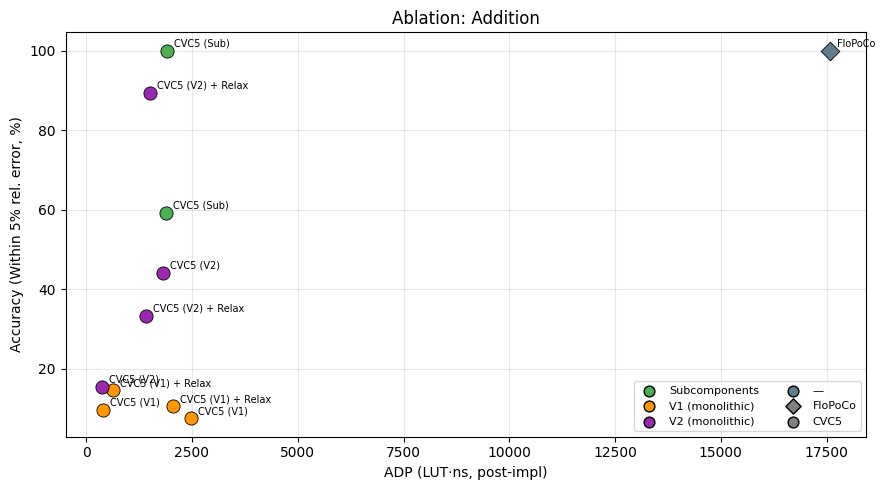

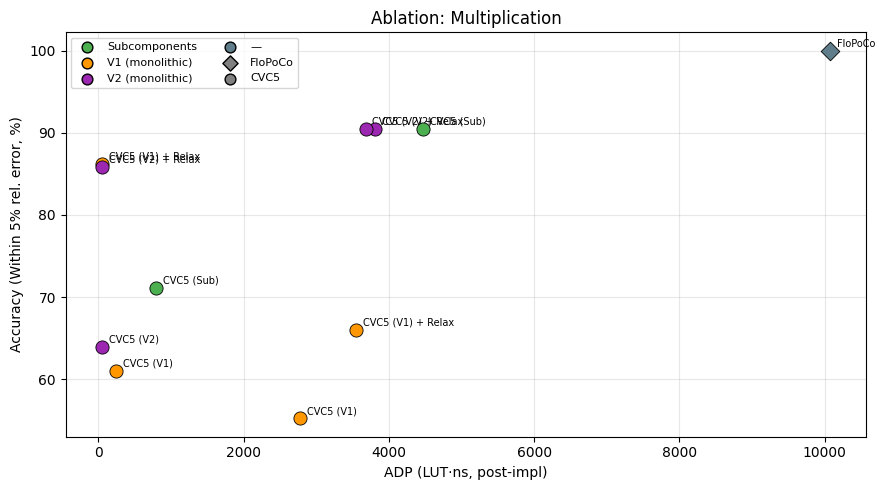

In [22]:
# ──────── Ablation Study: Factorial Table ────────
# Configs split by grammar track:
#   Subcomponents track: CVC5 (Sub)  →  CVC5 (Sub) + BV
#   Monolithic track:    CVC5 (V1)   →  CVC5 (V1) + Relaxation
#                        CVC5 (V2)   →  CVC5 (V2) + Relaxation
# Relaxation and BV Search are mutually exclusive — different grammar approaches.

if "merged" not in globals():
    raise RuntimeError("Run Section 1 first to populate merged dataframe.")

def _best_bv(bv_dataframe, family, target_name):
    """Return (LUTs, FFs, DSPs, accuracy%) for the best BV sweep point, or (nan,nan,nan,nan)."""
    if bv_dataframe is None or bv_dataframe.empty:
        return np.nan, np.nan, np.nan, np.nan
    acc_col = "within_rel_pct" if "within_rel_pct" in bv_dataframe.columns else "accuracy_exact_match"
    mask = bv_dataframe["family"] == family
    if target_name:
        mask = mask & (bv_dataframe["target"] == target_name)
    subset = bv_dataframe[mask].dropna(subset=[acc_col, "LUTs"])
    if subset.empty:
        return np.nan, np.nan, np.nan, np.nan
    best = subset.loc[subset[acc_col].idxmax()]
    acc_val = float(best[acc_col]) * 100 if float(best[acc_col]) <= 1.0 else float(best[acc_col])
    return best.get("LUTs", np.nan), best.get("FFs", np.nan), best.get("DSPs", np.nan), acc_val

# BV data (populated by Cell 19)
_bv = globals().get("bv_df", pd.DataFrame())

# Best relaxation-sweep result per (benchmark, variant, relax_mode)
# rsweep_df populated by Cell 15; falls back to pipeline row if absent.
_rsweep = globals().get("rsweep_df", pd.DataFrame())

def _best_relax(op, dtype, variant):
    """Return hardware row dict from best relaxation sweep result, or None."""
    if _rsweep.empty:
        return None
    bench = ("fp32_add" if (op == "Addition" and dtype == "FP32") else
             "fp32_mul" if (op == "Multiplication" and dtype == "FP32") else
             "mxint8_add" if (op == "Addition" and dtype == "MXINT8") else
             "mxint8_mul")
    sub = _rsweep[(_rsweep["benchmark"] == bench) & (_rsweep["variant"] == variant)
                  & (_rsweep["relax_mode"] == "staged")]
    sub = sub.dropna(subset=["adp_lut_ns"])
    if sub.empty:
        return None
    best = sub.loc[sub["adp_lut_ns"].idxmin()]
    return best.to_dict()

bv_targets = {
    ("Addition",       "MXINT8"): "mxint8_add",
    ("Addition",       "FP32"):   "fp32_add",
    ("Multiplication", "MXINT8"): "mxint8_mul",
    ("Multiplication", "FP32"):   "fp32_mul",
}

ablation_rows = []

for op in ["Addition", "Multiplication"]:
    for dtype in ["MXINT8", "FP32"]:
        bv_tgt = bv_targets.get((op, dtype), "")

        # ── FloPoCo baseline (FP32 only) ──────────────────────────────────────
        if dtype == "FP32":
            fp_row = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == "Flopoco")]
            if not fp_row.empty:
                r = fp_row.iloc[0]
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "FloPoCo",
                    "Grammar": "—", "Source": "FloPoCo", "Relaxation": "—", "BV Search": "—",
                    "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                    "Fmax_MHz": r.get("Fmax_MHz"), "Latency_ns": r.get("Latency_ns"), "Accuracy (%)": r.get("within5pct"),
                })

            bv_luts, bv_ffs, bv_dsps, bv_acc = _best_bv(_bv, "flopoco", bv_tgt)
            if not np.isnan(bv_acc):
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "FloPoCo + BV",
                    "Grammar": "—", "Source": "FloPoCo", "Relaxation": "—", "BV Search": "✓",
                    "LUTs": bv_luts, "FFs": bv_ffs, "DSPs": bv_dsps,
                    "Fmax_MHz": np.nan, "Accuracy (%)": bv_acc,
                })

        # ── Subcomponents track: CVC5 (Sub) and CVC5 (Sub) + BV ──────────────
        sub_row = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == "Subcomponents")]
        if not sub_row.empty:
            r = sub_row.iloc[0]
            ablation_rows.append({
                "Op": op, "Dtype": dtype, "Config": "CVC5 (Sub)",
                "Grammar": "Subcomponents", "Source": "CVC5", "Relaxation": "—", "BV Search": "—",
                "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                "Fmax_MHz": r.get("Fmax_MHz"), "Latency_ns": r.get("Latency_ns"), "Accuracy (%)": r.get("within5pct"),
            })

            bv_luts, bv_ffs, bv_dsps, bv_acc = _best_bv(_bv, "synthesised", bv_tgt)
            if not np.isnan(bv_acc):
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": "CVC5 (Sub) + BV",
                    "Grammar": "Subcomponents", "Source": "CVC5", "Relaxation": "—", "BV Search": "✓",
                    "LUTs": bv_luts, "FFs": bv_ffs, "DSPs": bv_dsps,
                    "Fmax_MHz": np.nan, "Accuracy (%)": bv_acc,
                })

        # ── Monolithic track: V1 and V2, each with and without Relaxation ─────
        for variant_label in ["V1", "V2"]:
            v_row = merged[(merged["op"] == op) & (merged["dtype"] == dtype) & (merged["variant"] == variant_label)]
            if v_row.empty:
                continue
            r = v_row.iloc[0]
            ablation_rows.append({
                "Op": op, "Dtype": dtype, "Config": f"CVC5 ({variant_label})",
                "Grammar": f"{variant_label} (monolithic)", "Source": "CVC5", "Relaxation": "—", "BV Search": "—",
                "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                "Fmax_MHz": r.get("Fmax_MHz"), "Latency_ns": r.get("Latency_ns"), "Accuracy (%)": r.get("within5pct"),
            })

            # Relaxation: use best staged result from relaxation sweep if available,
            # otherwise fall back to the pipeline row (which was synthesised with relaxation).
            relax_result = _best_relax(op, dtype, variant_label)
            if relax_result is not None:
                _relax_acc = relax_result.get("within_rel_pct")
                if _relax_acc is not None and _relax_acc <= 1.0:
                    _relax_acc = _relax_acc * 100  # fraction → percentage
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": f"CVC5 ({variant_label}) + Relax",
                    "Grammar": f"{variant_label} (monolithic)", "Source": "CVC5", "Relaxation": "✓", "BV Search": "—",
                    "LUTs": relax_result.get("luts"), "FFs": relax_result.get("ffs"),
                    "DSPs": relax_result.get("dsps"), "Fmax_MHz": relax_result.get("fmax_mhz"), "Latency_ns": relax_result.get("latency_ns"),
                    "Accuracy (%)": _relax_acc,
                })
            else:
                # Fallback: pipeline row (relaxation was applied during synthesis)
                ablation_rows.append({
                    "Op": op, "Dtype": dtype, "Config": f"CVC5 ({variant_label}) + Relax",
                    "Grammar": f"{variant_label} (monolithic)", "Source": "CVC5", "Relaxation": "✓ (pipeline)", "BV Search": "—",
                    "LUTs": r.get("LUTs"), "FFs": r.get("FFs"), "DSPs": r.get("DSPs"),
                    "Fmax_MHz": r.get("Fmax_MHz"), "Latency_ns": r.get("Latency_ns"), "Accuracy (%)": r.get("within5pct"),
                    "_note": "relaxation sweep unavailable; using pipeline result",
                })

if not ablation_rows:
    print("No ablation data available. Run Section 1 first.")
else:
    abl_df = pd.DataFrame(ablation_rows)
    abl_df["LUT_equiv"] = abl_df["LUTs"].fillna(0) + abl_df["DSPs"].fillna(0) * 150
    # ADP = LUT_equiv × Latency_ns (accounts for pipeline depth).
    # Fall back to single-cycle estimate if Latency_ns unavailable.
    if "Latency_ns" in abl_df.columns and abl_df["Latency_ns"].notna().any():
        abl_df["ADP (LUT·ns)"] = (abl_df["LUT_equiv"] * abl_df["Latency_ns"]).where(
            abl_df["Latency_ns"].notna())
    else:
        abl_df["ADP (LUT·ns)"] = (
            abl_df["LUT_equiv"] * (1000.0 / abl_df["Fmax_MHz"].replace(0, np.nan))
        ).where(abl_df["Fmax_MHz"].notna())

    display_cols = ["Op", "Dtype", "Config", "Grammar", "Source", "Relaxation", "BV Search",
                    "LUTs", "FFs", "DSPs", "Fmax_MHz", "ADP (LUT·ns)", "Accuracy (%)"]
    display_cols = [c for c in display_cols if c in abl_df.columns]

    print("Ablation Study: Factorial Comparison")
    print("=" * 110)
    display(abl_df[display_cols].reset_index(drop=True))

    # ── Chart: ADP vs Accuracy per operation ──
    track_colors = {
        "Subcomponents": "#4CAF50",
        "V1 (monolithic)": "#FF9800",
        "V2 (monolithic)": "#9C27B0",
        "—": "#607D8B",
    }
    source_markers = {"FloPoCo": "D", "CVC5": "o"}
    dtype_hatches = {"MXINT8": "//", "FP32": ""}

    for op in ["Addition", "Multiplication"]:
        odf = abl_df[abl_df["Op"] == op].dropna(subset=["ADP (LUT·ns)", "Accuracy (%)"])
        if odf.empty:
            continue
        fig, ax = plt.subplots(figsize=(9, 5))
        for _, row in odf.iterrows():
            color = track_colors.get(str(row.get("Grammar", "—")), "gray")
            marker = source_markers.get(row["Source"], "x")
            ax.scatter(row["ADP (LUT·ns)"], row["Accuracy (%)"],
                       marker=marker, color=color, s=90,
                       edgecolors="black", linewidth=0.6, zorder=5)
            ax.annotate(row["Config"], (row["ADP (LUT·ns)"], row["Accuracy (%)"]),
                        fontsize=7, xytext=(5, 3), textcoords="offset points")
        for grammar, c in track_colors.items():
            ax.scatter([], [], color=c, marker="o", label=grammar, edgecolors="black", s=60)
        for src, m in source_markers.items():
            ax.scatter([], [], color="gray", marker=m, label=src, edgecolors="black", s=60)
        ax.set_xlabel("ADP (LUT·ns, post-impl)")
        ax.set_ylabel("Accuracy (Within 5% rel. error, %)")
        ax.set_title(f"Ablation: {op}")
        ax.legend(fontsize=8, ncol=2)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


## 4b. Constraint Relaxation Analysis

In [7]:
# Load synthesis summary JSONs and extract relaxation info from per-attempt data.
# Each attempt has a "bits" field showing the MSB match level.

SUMMARY_GLOBS = [
    ROOT / "results" / "notebooks" / "latest_unified_results.json",
]
# Also scan raw hyperparameter sweep summaries for relaxation data.
relax_rows = []

for summary_dir in sorted((ROOT / "results" / "HLS").glob("solution_*")):
    # Look for the synthesis summary JSON inside each solution dir
    for summary_file in summary_dir.glob("synthesis_summary.json"):
        try:
            s = json.loads(summary_file.read_text())
        except Exception:
            continue
        for comp_name, comp in s.get("components", {}).items():
            attempts = comp.get("attempts", [])
            if not attempts:
                continue
            bits_values = [a.get("bits", -1) for a in attempts if a.get("bits", -1) > 0]
            if not bits_values:
                continue
            max_bits = max(bits_values)
            min_bits = min(bits_values)
            accepted = comp.get("accepted_constraints", 0)
            total = comp.get("total_constraints", 0)
            relaxed_count = sum(1 for a in attempts if a.get("bits", max_bits) < max_bits)
            relax_rows.append({
                "solution": summary_dir.name,
                "component": comp_name,
                "max_msb_bits": max_bits,
                "min_msb_bits": min_bits,
                "relaxation_range": max_bits - min_bits,
                "total_attempts": len(attempts),
                "relaxed_attempts": relaxed_count,
                "accepted": accepted,
                "total": total,
            })

if relax_rows:
    relax_df = pd.DataFrame(relax_rows)
    print(f"Found relaxation data for {len(relax_df)} components")
    display(relax_df.sort_values("relaxation_range", ascending=False).reset_index(drop=True))
else:
    print("No relaxation data found in synthesis summaries.")
    print("Relaxation analysis requires synthesis_summary.json files with per-attempt data.")

No relaxation data found in synthesis summaries.
Relaxation analysis requires synthesis_summary.json files with per-attempt data.


In [ ]:
# ──────── 4b-ii. Relaxation Sweep Analysis (runs.jsonl) ────────
# Reads from results/relaxation_sweep/run1_{mode}/runs.jsonl for each cocotb mode.
# Shows hardware quality (ADP, LUTs, Fmax), accuracy (within_rel_pct),
# and constraint stats across benchmarks, variants (V1/V2), relaxation modes
# (fixed/staged), bit levels, and cocotb operand modes (normal_full/small/wide).

RELAX_BASE = ROOT / "results" / "relaxation_sweep"
COCOTB_MODES = ["normal_full", "small", "wide"]

rsweep_frames = []
for mode in COCOTB_MODES:
    jsonl_path = RELAX_BASE / f"run1_{mode}" / "runs.jsonl"
    if not jsonl_path.exists():
        print(f"[SKIP] {jsonl_path}")
        continue
    rows = [json.loads(l) for l in jsonl_path.read_text().strip().splitlines()]
    for r in rows:
        r["cocotb_mode"] = mode
    rsweep_frames.extend(rows)
    print(f"[OK] {jsonl_path.name}: {len(rows)} rows (mode={mode})")

# Also check legacy single-dir layout as fallback
if not rsweep_frames:
    legacy = RELAX_BASE / "run1" / "runs.jsonl"
    if legacy.exists():
        rows = [json.loads(l) for l in legacy.read_text().strip().splitlines()]
        for r in rows:
            r["cocotb_mode"] = "normal_full"
        rsweep_frames.extend(rows)
        print(f"[OK] Legacy: {legacy} ({len(rows)} rows)")

if not rsweep_frames:
    print(f"No relaxation sweep results found under {RELAX_BASE}")
    rsweep_df = pd.DataFrame()
else:
    rsweep_df = pd.DataFrame(rsweep_frames)

    # Replace sentinel -1 values with NaN
    sentinel_cols = ["luts", "ffs", "dsps", "fmax_mhz", "latency_ns", "adp_lut_ns",
                     "within_rel_pct", "abs_err_avg", "abs_err_max",
                     "accepted_constraints", "true_skips", "accepted_used_relaxation",
                     "total_constraints", "wall_seconds"]
    for col in sentinel_cols:
        if col in rsweep_df.columns:
            rsweep_df[col] = pd.to_numeric(rsweep_df[col], errors="coerce")
            rsweep_df.loc[rsweep_df[col] < 0, col] = np.nan

    # ── Completion summary ───────────────────────────────────────────────────
    print(f"\nTotal: {len(rsweep_df)} runs across {rsweep_df['cocotb_mode'].nunique()} cocotb mode(s)")
    comp_tbl = rsweep_df.groupby(["cocotb_mode", "benchmark", "variant"]).size().reset_index(name="runs")
    display(comp_tbl.pivot_table(index=["benchmark", "variant"], columns="cocotb_mode",
                                 values="runs", fill_value=0, aggfunc="sum"))

    # ── Aggregate: mean across repetitions ──────────────────────────────────
    nominal = rsweep_df[rsweep_df.get("budget", pd.Series("nominal", index=rsweep_df.index)) != "stress"].copy() \
              if "budget" in rsweep_df.columns else rsweep_df.copy()

    GROUP = ["cocotb_mode", "benchmark", "variant", "relax_mode", "match_bits"]
    METRICS = ["luts", "fmax_mhz", "adp_lut_ns", "within_rel_pct",
               "accepted_constraints", "true_skips", "accepted_used_relaxation",
               "total_constraints", "wall_seconds"]
    agg = nominal.groupby(GROUP)[[m for m in METRICS if m in nominal.columns]].mean().reset_index()
    agg["within_pct"]  = agg["within_rel_pct"] * 100
    if "true_skips" in agg.columns and "total_constraints" in agg.columns:
        agg["skip_pct"]    = agg["true_skips"]              / agg["total_constraints"] * 100
        agg["accept_pct"]  = agg["accepted_constraints"]    / agg["total_constraints"] * 100
        agg["relaxed_pct"] = agg["accepted_used_relaxation"]/ agg["total_constraints"] * 100

    # ── Fig 1: ADP and Accuracy vs bit level per benchmark (normal_full mode) ──
    BENCHES = [b for b in ["fp32_add", "fp32_mul", "mxint8_add", "mxint8_mul"]
               if b in agg["benchmark"].values]
    V_COLORS  = {"V1": "#2196F3", "V2": "#E53935"}
    M_STYLES  = {"fixed": "-",    "staged": "--"}
    M_MARKERS = {"fixed": "o",    "staged": "s"}

    agg_nf = agg[agg["cocotb_mode"] == "normal_full"] if "normal_full" in agg["cocotb_mode"].values else agg
    n_bench = max(len(BENCHES), 1)

    fig, axes = plt.subplots(2, n_bench, figsize=(4.5 * n_bench, 9),
                             squeeze=False)
    for col, bench in enumerate(BENCHES):
        ax_adp = axes[0, col]
        ax_acc = axes[1, col]
        bdf = agg_nf[agg_nf["benchmark"] == bench]
        for var in ["V1", "V2"]:
            for mode in ["fixed", "staged"]:
                sub = bdf[(bdf["variant"] == var) & (bdf["relax_mode"] == mode)].sort_values("match_bits")
                if sub.empty:
                    continue
                kw = dict(color=V_COLORS[var], linestyle=M_STYLES[mode],
                          marker=M_MARKERS[mode], markersize=5, label=f"{var} {mode}")
                ax_adp.plot(sub["match_bits"], sub["adp_lut_ns"], **kw)
                ax_acc.plot(sub["match_bits"], sub["within_pct"], **kw)

        ax_adp.set_title(bench.replace("_", " ").upper(), fontsize=11, fontweight="bold")
        ax_adp.set_ylabel("ADP (LUT·ns)")
        ax_adp.legend(fontsize=7)
        ax_adp.grid(True, alpha=0.3)

        ax_acc.set_xlabel("Match bits")
        ax_acc.set_ylabel("Within-rel % (mean across reps)")
        ax_acc.set_ylim(0, 108)
        ax_acc.legend(fontsize=7)
        ax_acc.grid(True, alpha=0.3)

    fig.suptitle("Relaxation Sweep — ADP (top) and Accuracy (bottom) vs Match Bits\n"
                 "(normal_full mode, nominal budget)", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Fig 2: Cross-mode accuracy comparison ───────────────────────────────
    # For each benchmark × variant, compare accuracy at the best ADP config across modes
    if rsweep_df["cocotb_mode"].nunique() > 1:
        fig, axes = plt.subplots(1, n_bench, figsize=(4.5 * n_bench, 5),
                                 squeeze=False, constrained_layout=True)
        MODE_COLORS = {"normal_full": "#2196F3", "small": "#4CAF50", "wide": "#FF9800"}
        for col_idx, bench in enumerate(BENCHES):
            ax = axes[0, col_idx]
            for var in ["V1", "V2"]:
                x_vals, y_vals, labels = [], [], []
                for mode in COCOTB_MODES:
                    sub = agg[(agg["cocotb_mode"] == mode) & (agg["benchmark"] == bench)
                              & (agg["variant"] == var) & (agg["relax_mode"] == "staged")]
                    if sub.empty:
                        sub = agg[(agg["cocotb_mode"] == mode) & (agg["benchmark"] == bench)
                                  & (agg["variant"] == var)]
                    if sub.empty:
                        continue
                    best = sub.loc[sub["adp_lut_ns"].idxmin()] if sub["adp_lut_ns"].notna().any() else sub.iloc[0]
                    x_vals.append(mode)
                    y_vals.append(best["within_pct"])
                    labels.append(f"{var}")
                if x_vals:
                    ax.bar([f"{x}\n{var}" for x in x_vals], y_vals,
                           color=[MODE_COLORS.get(x, "gray") for x in x_vals],
                           edgecolor="white", width=0.6)
            ax.set_title(bench.replace("_", " ").upper(), fontsize=10, fontweight="bold")
            ax.set_ylabel("Within-rel %")
            ax.set_ylim(0, 108)
            ax.grid(axis="y", alpha=0.3)
            ax.tick_params(axis="x", labelsize=7)

        fig.suptitle("Relaxation Sweep — Accuracy by Cocotb Mode (best ADP config)", fontsize=12)
        plt.show()

    # ── Fig 3: Constraint outcomes + V1 vs V2 ADP scatter ───────────────────
    fig, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar: acceptance / skip / relaxed at max bits (fixed, nominal, normal_full)
    max_fixed = (agg_nf[agg_nf["relax_mode"] == "fixed"]
                 .loc[agg_nf[agg_nf["relax_mode"] == "fixed"]
                      .groupby(["benchmark", "variant"])["match_bits"].idxmax()])
    max_fixed = max_fixed.copy()
    max_fixed["label"] = max_fixed["benchmark"].str.replace("_", "\n") + "\n" + max_fixed["variant"]
    max_fixed = max_fixed.sort_values(["benchmark", "variant"])
    x = np.arange(len(max_fixed))
    w = 0.28
    if "accept_pct" in max_fixed.columns:
        ax_bar.bar(x - w,   max_fixed["accept_pct"],  w, label="Accepted",             color="#4CAF50")
        ax_bar.bar(x,       max_fixed["relaxed_pct"], w, label="Accepted via relax",   color="#FF9800")
        ax_bar.bar(x + w,   max_fixed["skip_pct"],    w, label="Skipped (timeout)",    color="#F44336")
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(max_fixed["label"], fontsize=7)
    ax_bar.set_ylabel("% of constraints")
    ax_bar.set_title("Constraint Outcomes at Max Bits (fixed, normal_full)")
    ax_bar.legend(fontsize=8)
    ax_bar.grid(True, alpha=0.3, axis="y")

    # Scatter: V1 ADP vs V2 ADP at matching bit levels (normal_full)
    v1_fixed = agg_nf[(agg_nf["variant"] == "V1") & (agg_nf["relax_mode"] == "fixed")][
        ["benchmark", "match_bits", "adp_lut_ns", "within_pct"]].rename(
        columns={"adp_lut_ns": "adp_v1", "within_pct": "within_v1"})
    v2_fixed = agg_nf[(agg_nf["variant"] == "V2") & (agg_nf["relax_mode"] == "fixed")][
        ["benchmark", "match_bits", "adp_lut_ns", "within_pct"]].rename(
        columns={"adp_lut_ns": "adp_v2", "within_pct": "within_v2"})
    vv = v1_fixed.merge(v2_fixed, on=["benchmark", "match_bits"])
    if not vv.empty:
        bench_colors = {"fp32_add": "#1565C0", "fp32_mul": "#2E7D32",
                        "mxint8_add": "#AD1457", "mxint8_mul": "#E65100"}
        for bench in vv["benchmark"].unique():
            sub = vv[vv["benchmark"] == bench]
            ax_scatter.scatter(sub["adp_v1"], sub["adp_v2"],
                               c=bench_colors.get(bench, "grey"), label=bench,
                               s=60, alpha=0.8, zorder=3)
        lim = vv[["adp_v1", "adp_v2"]].max().max() * 1.08
        ax_scatter.plot([0, lim], [0, lim], "k--", alpha=0.4, label="V1 = V2")
        ax_scatter.set_xlabel("V1 ADP (LUT·ns)")
        ax_scatter.set_ylabel("V2 ADP (LUT·ns)")
        ax_scatter.set_title("V1 vs V2 ADP — fixed mode\n(below diagonal = V2 better)")
        ax_scatter.legend(fontsize=8)
        ax_scatter.grid(True, alpha=0.3)

    fig.suptitle("Relaxation Sweep — Constraint Stats & V1 vs V2 Comparison", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Best config per benchmark/variant (lowest ADP, nominal, normal_full) ─
    best_idx = agg_nf.groupby(["benchmark", "variant"])["adp_lut_ns"].idxmin()
    best_cols = ["benchmark", "variant", "relax_mode", "match_bits",
                 "luts", "fmax_mhz", "adp_lut_ns", "within_pct"]
    if "accept_pct" in agg_nf.columns:
        best_cols += ["accept_pct", "skip_pct"]
    best = agg_nf.loc[best_idx][[c for c in best_cols if c in agg_nf.columns]].rename(
        columns={"luts": "LUTs", "fmax_mhz": "Fmax_MHz", "adp_lut_ns": "ADP",
                 "within_pct": "Within%", "accept_pct": "Accept%", "skip_pct": "Skip%"})
    print("\nBest ADP configuration per benchmark/variant (mean across reps, normal_full):")
    display(best.round(1).reset_index(drop=True))

## 4c. Bitvector Width Sweep

Optimises area by truncating mantissa bit-widths while maintaining accuracy within a threshold.
Runs for both CVC5-synthesised and FloPoCo designs.

In [ ]:
# ──────── Load Bitvector Sweep Results ────────
# Scans results/sweeps/ for summary CSVs from both synthesised and FloPoCo BV sweeps.
# Robust to different directory layouts (all-targets combined, per-target, per-mode).

PROD_SWEEPS_ROOT = ROOT / "results" / "sweeps"
frames = []
_seen_files: set[str] = set()

def _load_csv(path, family, default_mode=""):
    """Load a summary CSV, tag with family and cocotb_mode, deduplicate by file path."""
    key = str(path.resolve())
    if key in _seen_files:
        return
    _seen_files.add(key)
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[WARN] Failed to read {path}: {e}")
        return
    if df.empty:
        return
    df["family"] = family
    # Use cocotb_mode from data if present, else from directory name or default
    if "cocotb_mode" not in df.columns:
        # Try to infer from parent directory name (e.g., "normal_full", "small", "wide")
        parent_name = path.parent.name.lower()
        if parent_name in ("normal_full", "small", "wide"):
            df["cocotb_mode"] = parent_name
        else:
            df["cocotb_mode"] = default_mode
    df["cocotb_mode_config"] = df["cocotb_mode"]
    df["rel_error_pct_config"] = pd.to_numeric(
        df["within_rel_threshold_pct"], errors="coerce"
    ) if "within_rel_threshold_pct" in df.columns else float("nan")
    df["run_dir"] = str(path.parent)
    frames.append(df)

# ── 1. Synthesised BV sweeps ────────────────────────────────────────────────
# Combined summaries from --all-targets mode
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/summary_all_targets.csv")):
    _load_csv(csv_path, "synthesised")
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/*/summary_all_targets.csv")):
    _load_csv(csv_path, "synthesised")

# Per-target summaries (single-target mode or per-mode subdirs)
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/summary.csv")):
    _load_csv(csv_path, "synthesised")
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/*/summary.csv")):
    _load_csv(csv_path, "synthesised")

# Legacy per-target directories: bitvector_{target}/
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_*/summary.csv")):
    if "flopoco" in csv_path.parent.name or csv_path.parent.name == "bitvector_all":
        continue
    _load_csv(csv_path, "synthesised")

# Also check summary.json as fallback (same data, JSON format)
for json_path in sorted(PROD_SWEEPS_ROOT.glob("bitvector_all/**/summary.json")):
    key = str(json_path.resolve())
    csv_sibling = json_path.with_name("summary.csv")
    if str(csv_sibling.resolve()) in _seen_files:
        continue  # CSV already loaded
    if key in _seen_files:
        continue
    _seen_files.add(key)
    try:
        data = json.loads(json_path.read_text())
        if isinstance(data, list) and data:
            df = pd.DataFrame(data)
            df["family"] = "synthesised"
            if "cocotb_mode" not in df.columns:
                df["cocotb_mode"] = ""
            df["cocotb_mode_config"] = df["cocotb_mode"]
            df["rel_error_pct_config"] = pd.to_numeric(
                df["within_rel_threshold_pct"], errors="coerce"
            ) if "within_rel_threshold_pct" in df.columns else float("nan")
            df["run_dir"] = str(json_path.parent)
            frames.append(df)
    except Exception:
        pass

# ── 2. FloPoCo BV sweeps ───────────────────────────────────────────────────
# Prefer impl dirs over non-impl dirs
_flopoco_targets_with_impl: set[str] = set()

# Pass 1: impl mode-level subdirectories
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_impl_*/*/summary.csv")):
    _load_csv(csv_path, "flopoco")
    try:
        df = pd.read_csv(csv_path)
        if "target" in df.columns:
            _flopoco_targets_with_impl.update(df["target"].unique())
    except Exception:
        pass

# Pass 2: impl parent summaries (only if no mode-subdirectory)
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_impl_*/summary.csv")):
    _load_csv(csv_path, "flopoco")
    try:
        df = pd.read_csv(csv_path)
        if "target" in df.columns:
            _flopoco_targets_with_impl.update(df["target"].unique())
    except Exception:
        pass

# Pass 3: non-impl dirs (only for targets without impl data)
for csv_path in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_*/summary.csv")):
    if "impl" in csv_path.parent.name:
        continue
    try:
        df = pd.read_csv(csv_path)
        if "target" in df.columns and set(df["target"].unique()).issubset(_flopoco_targets_with_impl):
            continue
    except Exception:
        pass
    _load_csv(csv_path, "flopoco")

# ── 3. Build combined DataFrame ────────────────────────────────────────────
if not frames:
    print(f"No sweep summaries found under {PROD_SWEEPS_ROOT}")
    print("BV sweeps are deferred — launch them after pipeline sessions finish.")
    bv_df = pd.DataFrame()
else:
    bv_df = pd.concat(frames, ignore_index=True)

    # Deduplicate: same (target, cocotb_mode, mantissa_bits, family) = same experiment
    dedup_cols = [c for c in ["target", "cocotb_mode", "mantissa_bits", "exponent_bits", "family"]
                  if c in bv_df.columns]
    if dedup_cols:
        before = len(bv_df)
        bv_df = bv_df.drop_duplicates(subset=dedup_cols, keep="last")
        if before != len(bv_df):
            print(f"Deduplicated: {before} -> {len(bv_df)} rows")

    for col in ["mantissa_bits", "accuracy_exact_match", "within_rel_pct", "within_5pct_rel",
                "abs_err_avg", "abs_err_p99", "abs_err_max",
                "LUTs", "FFs", "DSPs", "BRAMs", "Fmax_MHz", "Latency_ns", "area_score",
                "adp_lut_ns", "rel_error_pct_config"]:
        if col in bv_df.columns:
            bv_df[col] = pd.to_numeric(bv_df[col], errors="coerce")
            bv_df.loc[bv_df[col] < 0, col] = np.nan

    print(f"Loaded {len(bv_df)} rows from {len(frames)} summaries")
    print("Families:", sorted(bv_df["family"].unique()))
    if "cocotb_mode" in bv_df.columns:
        print("Cocotb modes:", sorted(bv_df["cocotb_mode"].dropna().unique()))
    if "target" in bv_df.columns:
        print("Targets:", sorted(bv_df["target"].dropna().unique()))

In [ ]:
# ──────── Violin + Strip Plots: Per-Sample Relative Error ────────
# Loads NPZ files from BV sweeps AND relaxation sweep error_samples/ directories.
# Groups by target (component) and cocotb mode for side-by-side comparison.

def find_npz_files(base):
    """Find all per-sample error dump NPZ files under base."""
    return sorted(Path(base).rglob("error_samples/*.npz")) if Path(base).exists() else []

# ── Collect NPZ files from all experiment sources ──
all_npz = []

# BV sweep NPZ files
all_npz += find_npz_files(PROD_SWEEPS_ROOT / "bitvector_all")
for d in sorted(PROD_SWEEPS_ROOT.glob("flopoco_bitvector_*")):
    all_npz += find_npz_files(d)
for d in sorted(PROD_SWEEPS_ROOT.glob("bitvector_*")):
    if d.name != "bitvector_all" and "flopoco" not in d.name:
        all_npz += find_npz_files(d)

# Relaxation sweep NPZ files (per-mode directories)
RELAX_BASE = ROOT / "results" / "relaxation_sweep"
for mode_dir in sorted(RELAX_BASE.glob("run1_*")):
    all_npz += find_npz_files(mode_dir)
# Legacy single dir
all_npz += find_npz_files(RELAX_BASE / "run1")

# Deduplicate by resolved path
seen = set()
all_npz = [p for p in all_npz if not (str(p.resolve()) in seen or seen.add(str(p.resolve())))]
print(f"Found {len(all_npz)} per-sample NPZ files")

if all_npz:
    # Parse each NPZ into a structured record
    npz_records = []
    for npz_path in all_npz:
        data = np.load(npz_path, allow_pickle=True)
        # Extract errors (relative or absolute)
        if "rel_err_pct" in data:
            errors = np.abs(data["rel_err_pct"])
            err_type = "rel_pct"
        elif "abs_err_quant" in data:
            full_scale = float(data["full_scale"][0]) if "full_scale" in data else 112.0
            errors = np.abs(data["abs_err_quant"]) / full_scale * 100.0
            err_type = "abs_scaled_pct"
        else:
            continue

        # Extract cocotb mode from NPZ metadata or directory name
        sample_mode = "unknown"
        if "sample_mode" in data:
            sample_mode = str(data["sample_mode"][0])
        else:
            # Infer from directory: run1_normal_full, run1_small, run1_wide
            for part in npz_path.parts:
                if part.startswith("run1_"):
                    sample_mode = part.replace("run1_", "")
                    break
                if part in ("normal_full", "small", "wide"):
                    sample_mode = part
                    break

        # Infer target from filename
        stem = npz_path.stem
        target = "unknown"
        for t in ["fp32_add", "fp32_mul", "mxint8_add", "mxint8_mul"]:
            if t in stem:
                target = t
                break

        # Infer source (bv_sweep vs relaxation)
        source = "relaxation" if "relaxation_sweep" in str(npz_path) else "bv_sweep"

        npz_records.append({
            "path": npz_path,
            "errors": errors,
            "err_type": err_type,
            "mode": sample_mode,
            "target": target,
            "source": source,
            "label": stem,
        })

    print(f"Parsed {len(npz_records)} NPZ records")
    modes_found = sorted(set(r["mode"] for r in npz_records))
    targets_found = sorted(set(r["target"] for r in npz_records))
    print(f"Modes: {modes_found}, Targets: {targets_found}")

    # ── Fig 1: Per-target violin plots (all modes combined) ──
    target_errors = defaultdict(list)
    for rec in npz_records:
        target_errors[rec["target"]].append(rec["errors"])

    n_targets = min(len(target_errors), 4)
    if n_targets > 0:
        fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5),
                                 constrained_layout=True, squeeze=False)
        for idx, (target, err_arrays) in enumerate(sorted(target_errors.items())[:4]):
            ax = axes[0][idx]
            all_errs = np.concatenate(err_arrays)
            parts = ax.violinplot([all_errs], positions=[0], showmedians=True, showextrema=False)
            n_show = min(len(all_errs), 500)
            sample_idx = np.random.choice(len(all_errs), n_show, replace=False)
            ax.scatter(np.random.normal(0, 0.02, n_show), all_errs[sample_idx],
                       alpha=0.15, s=3, color="black", zorder=2)
            ax.axhline(y=1.0, color="red", linestyle="--", linewidth=0.8, label="1% threshold")
            ax.axhline(y=5.0, color="orange", linestyle="--", linewidth=0.8, label="5% threshold")
            ax.set_title(target.replace("_", " ").upper(), fontsize=10)
            ax.set_ylabel("Error (%)")
            ax.set_xticks([])
            ax.legend(fontsize=7)
        plt.suptitle("Per-Sample Error Distribution (All Modes)", fontsize=11)
        plt.show()

    # ── Fig 2: Per-mode violin comparison (side-by-side per target) ──
    MODE_COLORS = {"normal_full": "#2196F3", "small": "#4CAF50", "wide": "#FF9800", "unknown": "#999"}
    mode_target_errors = defaultdict(lambda: defaultdict(list))
    for rec in npz_records:
        mode_target_errors[rec["target"]][rec["mode"]].append(rec["errors"])

    n_targets = min(len(mode_target_errors), 4)
    if n_targets > 0 and len(modes_found) > 1:
        fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5),
                                 constrained_layout=True, squeeze=False)
        for idx, target in enumerate(sorted(mode_target_errors.keys())[:4]):
            ax = axes[0][idx]
            positions = []
            data_arrays = []
            tick_labels = []
            for j, mode in enumerate(["normal_full", "small", "wide"]):
                if mode in mode_target_errors[target]:
                    errs = np.concatenate(mode_target_errors[target][mode])
                    positions.append(j)
                    data_arrays.append(errs)
                    tick_labels.append(mode.replace("_", "\n"))
            if data_arrays:
                parts = ax.violinplot(data_arrays, positions=positions,
                                      showmedians=True, showextrema=False)
                for j, body in enumerate(parts["bodies"]):
                    mode_name = ["normal_full", "small", "wide"][positions[j]]
                    body.set_facecolor(MODE_COLORS.get(mode_name, "#999"))
                    body.set_alpha(0.7)
                ax.axhline(y=1.0, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
                ax.axhline(y=5.0, color="orange", linestyle="--", linewidth=0.8, alpha=0.5)
                ax.set_xticks(positions)
                ax.set_xticklabels(tick_labels, fontsize=8)
            ax.set_title(target.replace("_", " ").upper(), fontsize=10)
            ax.set_ylabel("Error (%)")
        plt.suptitle("Per-Sample Error by Cocotb Mode", fontsize=11)
        plt.show()
else:
    print("No per-sample NPZ files found. Run experiments first.")

In [ ]:
# ──────── Accuracy Threshold Chart (Log-Scale X-Axis) ────────
# For each design × mode, compute % of samples within each error threshold.
# Shows per-mode CDF curves to reveal how mode affects accuracy at different thresholds.

THRESHOLDS = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]

if "npz_records" in dir() and npz_records:
    # ── Fig 1: Per-target, one line per mode ──
    MODE_LINE = {"normal_full": ("-", "#2196F3"), "small": ("--", "#4CAF50"), "wide": ("-.", "#FF9800")}
    targets = sorted(set(r["target"] for r in npz_records if r["target"] != "unknown"))

    if targets:
        n_targets = min(len(targets), 4)
        fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5),
                                 constrained_layout=True, squeeze=False, sharey=True)
        for idx, target in enumerate(targets[:4]):
            ax = axes[0][idx]
            for mode in ["normal_full", "small", "wide"]:
                errs_list = [r["errors"] for r in npz_records
                             if r["target"] == target and r["mode"] == mode]
                if not errs_list:
                    continue
                all_errs = np.abs(np.concatenate(errs_list))
                pcts = [100.0 * np.mean(all_errs <= t) for t in THRESHOLDS]
                ls, color = MODE_LINE.get(mode, ("-", "gray"))
                ax.plot(THRESHOLDS, pcts, marker="o", markersize=4,
                        linestyle=ls, color=color, label=mode)
            ax.set_xscale("log")
            ax.set_xlabel("Error Threshold (%)")
            ax.set_title(target.replace("_", " ").upper(), fontsize=10)
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
            ax.set_ylim(0, 105)
        axes[0][0].set_ylabel("Samples Within Threshold (%)")
        fig.suptitle("Accuracy CDF by Cocotb Mode", fontsize=12)
        plt.show()

    # ── Fig 2: All designs on one plot (for overview) ──
    threshold_data = {}
    for rec in npz_records:
        key = f"{rec['target']}_{rec['mode']}" if rec["mode"] != "unknown" else rec["label"]
        all_errs = np.abs(rec["errors"])
        pcts = [100.0 * np.mean(all_errs <= t) for t in THRESHOLDS]
        if key not in threshold_data:
            threshold_data[key] = pcts
        else:
            # Average with existing (multiple NPZ files for same key)
            threshold_data[key] = [(a + b) / 2 for a, b in zip(threshold_data[key], pcts)]

    if threshold_data:
        fig, ax = plt.subplots(figsize=(9, 6))
        for label, pcts in sorted(threshold_data.items()):
            ax.plot(THRESHOLDS, pcts, marker="o", markersize=4, label=label)
        ax.set_xscale("log")
        ax.set_xlabel("Error Threshold (%)")
        ax.set_ylabel("Samples Within Threshold (%)")
        ax.set_title("Accuracy vs Error Threshold (All Designs)")
        ax.legend(fontsize=6, loc="lower right", ncol=2)
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 105)
        plt.tight_layout()
        plt.show()
else:
    print("No per-sample data available for threshold chart.")

In [ ]:
# ──────── Area vs Accuracy Pareto Front ────────
# Shows LUTs vs accuracy for all BV sweep points, colored by family and mode.
# Includes Pareto fronts per family and an ADP-based variant.

if "bv_df" in dir() and not bv_df.empty:
    acc_col = "within_rel_pct" if "within_rel_pct" in bv_df.columns else "accuracy_exact_match"
    area_col = "LUTs"

    bv_plot = bv_df.dropna(subset=[area_col, acc_col]).copy()
    bv_plot["acc_pct"] = np.where(bv_plot[acc_col] <= 1.0, bv_plot[acc_col] * 100, bv_plot[acc_col])

    if not bv_plot.empty:
        family_colors = {"synthesised": "#2196F3", "flopoco": "#FF5722"}
        mode_markers = {"normal_full": "o", "small": "s", "wide": "D", "": "x"}

        # ── Fig 1: LUTs vs Accuracy ──
        fig, ax = plt.subplots(figsize=(9, 6))
        for family in sorted(bv_plot["family"].unique()):
            fdf = bv_plot[bv_plot["family"] == family]
            for mode in sorted(fdf["cocotb_mode_config"].fillna("").unique()):
                mdf = fdf[fdf["cocotb_mode_config"].fillna("") == mode]
                marker = mode_markers.get(mode, "x")
                ax.scatter(mdf[area_col], mdf["acc_pct"],
                           label=f"{family} ({mode})" if mode else family,
                           alpha=0.6, s=30, marker=marker,
                           color=family_colors.get(family, "gray"),
                           edgecolors="black", linewidth=0.3)
            # Pareto front per family
            fdf_sorted = fdf.sort_values(area_col)
            pareto_x, pareto_y = [], []
            best_acc = -1
            for _, r in fdf_sorted.iterrows():
                if r["acc_pct"] > best_acc:
                    best_acc = r["acc_pct"]
                    pareto_x.append(r[area_col])
                    pareto_y.append(r["acc_pct"])
            if pareto_x:
                ax.plot(pareto_x, pareto_y, "--", color=family_colors.get(family, "gray"), alpha=0.5)

        ax.set_xlabel("LUTs")
        ax.set_ylabel("Accuracy (%)")
        ax.set_title("Bitvector Sweep: Area vs Accuracy Pareto Front")
        ax.legend(fontsize=7, loc="lower right")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        # ── Fig 2: ADP vs Accuracy (if ADP available) ──
        if "adp_lut_ns" in bv_plot.columns and bv_plot["adp_lut_ns"].notna().any():
            adp_plot = bv_plot.dropna(subset=["adp_lut_ns"])
            if not adp_plot.empty:
                fig, ax = plt.subplots(figsize=(9, 6))
                for family in sorted(adp_plot["family"].unique()):
                    fdf = adp_plot[adp_plot["family"] == family]
                    ax.scatter(fdf["adp_lut_ns"], fdf["acc_pct"],
                               label=family.title(), alpha=0.6, s=30,
                               color=family_colors.get(family, "gray"),
                               edgecolors="black", linewidth=0.3)
                ax.set_xlabel("ADP (LUT·ns)")
                ax.set_ylabel("Accuracy (%)")
                ax.set_title("Bitvector Sweep: ADP vs Accuracy")
                ax.legend(fontsize=8)
                ax.grid(alpha=0.3)
                plt.tight_layout()
                plt.show()
    else:
        print("No data with both area and accuracy for Pareto plot.")
else:
    print("No bitvector sweep data loaded.")

## 4d. Grammar Complexity vs Synthesis Time

Do grammars with larger (bounded) search spaces take longer to solve?  
Each synthesis target has a documented search-space size in its `.sl` template file.  
This cell correlates that count with the observed synthesis wall-clock time from Section 1,  
providing a principled justification for the structural-sketch grammar design decisions.

In [ ]:
# ──────── 4d. Grammar Complexity vs Synthesis Time ────────
# Uses grammar_selection study data if available (has per-run timing + grammar metrics),
# otherwise falls back to hardcoded search-space metadata.

GRAMMAR_META = [
    # (label, search_space, variant, benchmark, is_recursive)
    ("MXINT8 Add\nalignment",     192,   "Subcomponents", "mxint8_add", False),
    ("MXINT8 Add\nnormalisation", 270,   "Subcomponents", "mxint8_add", False),
    ("MXINT8 Add\ndetect_ovf",     75,   "Subcomponents", "mxint8_add", False),
    ("MXINT8 Add\nraw_sum",         1,   "Subcomponents", "mxint8_add", False),
    ("FP32 Add\nalignment",       480,   "Subcomponents", "fp32_add",   False),
    ("FP32 Add\nraw_sum",         288,   "Subcomponents", "fp32_add",   False),
    ("FP32 Add\nnormalisation",   240,   "Subcomponents", "fp32_add",   False),
    ("MXINT8 Mul\nmant",          108,   "Subcomponents", "mxint8_mul", False),
    ("MXINT8 Mul\nexp",          None,   "Subcomponents", "mxint8_mul", True),
    ("MXINT8 Mul\nrenorm_flag",  None,   "Subcomponents", "mxint8_mul", True),
    ("FP32 Mul\nexp",             360,   "Subcomponents", "fp32_mul",   False),
    ("FP32 Mul\nmant",           1458,   "Subcomponents", "fp32_mul",   False),
    ("FP32 Mul\nrenorm",           90,   "Subcomponents", "fp32_mul",   False),
    ("FP32 Mul\nround_carry",     216,   "Subcomponents", "fp32_mul",   False),
    ("MXINT8 Add V1",          27000,   "V1",            "mxint8_add", False),
    ("FP32 Add V1",            15500,   "V1",            "fp32_add",   False),
    ("MXINT8 Mul V1",         25000,   "V1",            "mxint8_mul", False),
    ("FP32 Mul V1",            27000,   "V1",            "fp32_mul",   False),
    ("MXINT8 Add V2",          10000,   "V2",            "mxint8_add", False),
    ("FP32 Add V2",             8000,   "V2",            "fp32_add",   False),
    ("MXINT8 Mul V2",          9000,   "V2",            "mxint8_mul", False),
    ("FP32 Mul V2",            12000,   "V2",            "fp32_mul",   False),
]

# ── Try to get synthesis times from grammar_selection study or pipeline logs ──
has_gs = "gs_df" in dir() and not gs_df.empty

gc_rows = []
for label, search_space, variant, benchmark, is_recursive in GRAMMAR_META:
    synth_time = None

    # Prefer grammar_selection study data
    if has_gs:
        sub = gs_df[(gs_df["benchmark"] == benchmark) & (gs_df["grammar_version"] == variant)]
        if not sub.empty and "solver_runtime_seconds_total" in sub.columns:
            synth_time = sub["solver_runtime_seconds_total"].mean()
            if pd.isna(synth_time) or synth_time < 0:
                synth_time = None

    gc_rows.append({
        "label": label,
        "search_space": search_space,
        "synth_time_s": synth_time,
        "recursive": is_recursive,
        "category": "V1" if "V1" in label else ("V2" if "V2" in label else ("Recursive" if is_recursive else "Subcomponent")),
    })

gc_df = pd.DataFrame(gc_rows)
has_times = gc_df["synth_time_s"].notna().any()

if not has_times:
    print("No synthesis timing data found. Run grammar selection study first.")
    print("Showing search-space bar chart only.\n")

# ── Plot 1: Search-space size bar chart ──
sketch_df = gc_df[~gc_df["recursive"]].copy().sort_values("search_space")
fig, ax = plt.subplots(figsize=(11, 5))
cat_colors = {"Subcomponent": "#4C72B0", "V1": "#DD8452", "V2": "#55A868"}
colors = sketch_df["category"].map(cat_colors).fillna("gray")
bars = ax.barh(sketch_df["label"],
               sketch_df["search_space"].apply(lambda x: np.log10(x) if x and x > 0 else 0),
               color=colors, edgecolor="white", height=0.7)
ax.set_xlabel("log10(Search Space Size)")
ax.set_title("Grammar Search Space Sizes")
for bar, (_, row) in zip(bars, sketch_df.iterrows()):
    if row["search_space"] and row["search_space"] > 0:
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{int(row['search_space']):,}", va="center", fontsize=8)
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in cat_colors.items()]
ax.legend(handles=legend_handles, loc="lower right")
plt.tight_layout()
plt.show()

# ── Plot 2: Search space vs synthesis time scatter ──
if has_times:
    plot_df = gc_df[~gc_df["recursive"] & gc_df["synth_time_s"].notna()].copy()
    fig, ax = plt.subplots(figsize=(7, 5))
    for cat, grp in plot_df.groupby("category"):
        color = cat_colors.get(cat, "gray")
        ax.scatter(np.log10(grp["search_space"].astype(float)), grp["synth_time_s"],
                   label=cat, color=color, s=70, zorder=3)
        for _, row in grp.iterrows():
            ax.annotate(row["label"], (np.log10(row["search_space"]), row["synth_time_s"]),
                        textcoords="offset points", xytext=(5, 2), fontsize=7, color="grey")
    xs = np.log10(plot_df["search_space"].astype(float))
    ys = plot_df["synth_time_s"].astype(float)
    if len(xs) >= 3:
        coeffs = np.polyfit(xs, ys, 1)
        xfit = np.linspace(xs.min(), xs.max(), 100)
        ax.plot(xfit, np.polyval(coeffs, xfit), "k--", linewidth=1, alpha=0.5, label="Linear fit")
        r2 = np.corrcoef(xs, ys)[0, 1] ** 2
        ax.set_title(f"Grammar Search Space vs Synthesis Time  (R2 = {r2:.2f})")
    else:
        ax.set_title("Grammar Search Space vs Synthesis Time")
    ax.set_xlabel("log10(Search Space Size)")
    ax.set_ylabel("Synthesis Time (s)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Summary table ──
tbl = gc_df[["label", "search_space", "synth_time_s", "category"]].copy()
tbl.columns = ["Grammar", "Search Space", "Synth Time (s)", "Type"]
tbl["Search Space"] = tbl["Search Space"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "Recursive")
tbl["Synth Time (s)"] = tbl["Synth Time (s)"].apply(lambda x: f"{x:.1f}" if pd.notna(x) else "\u2014")
display(tbl.reset_index(drop=True))

# 5. Cross-cutting Summary

Headline charts combining all experimental data.

In [ ]:
# ──────── Cross-Cutting Summary: Accuracy vs Area (All Approaches) ────────
# Combines: pipeline full-precision designs, best BV-reduced variants,
# best relaxation sweep configs, and FloPoCo baselines.
# Uses ADP (LUT·ns) as the primary area metric for efficiency comparison.

all_points = []

# ── Full-precision from pipeline (Section 1) ──
if "merged" in dir():
    for _, row in merged.dropna(subset=["LUTs"]).iterrows():
        lut_equiv = row["LUTs"] + row.get("DSPs", 0) * 150
        acc = row.get("within5pct", np.nan)
        adp = row.get("ADP", np.nan)
        all_points.append({
            "label": f"{row['dtype']} {row['op'][:3]} ({row['variant']})",
            "LUTs_equiv": lut_equiv, "ADP": adp, "accuracy": acc,
            "source": "Full Precision", "op": row["op"], "dtype": row["dtype"],
            "variant": row["variant"],
        })

# ── Best bitvector points (per family × target × mode) ──
if "bv_df" in dir() and not bv_df.empty:
    acc_col = "within_rel_pct" if "within_rel_pct" in bv_df.columns else "accuracy_exact_match"
    group_cols = ["family", "target"]
    if "cocotb_mode" in bv_df.columns:
        group_cols.append("cocotb_mode")
    for key, gdf in bv_df.groupby(group_cols):
        best = gdf.loc[gdf[acc_col].idxmax()] if not gdf[acc_col].isna().all() else None
        if best is not None and pd.notna(best.get("LUTs")):
            lut_equiv = best["LUTs"] + best.get("DSPs", 0) * 150
            acc_val = best[acc_col] * 100 if best[acc_col] <= 1.0 else best[acc_col]
            adp_val = best.get("adp_lut_ns", np.nan)
            mode_str = f" [{best.get('cocotb_mode', '')}]" if "cocotb_mode" in best.index and best.get("cocotb_mode") else ""
            family = key[0] if isinstance(key, tuple) else key
            target = key[1] if isinstance(key, tuple) else ""
            all_points.append({
                "label": f"BV {family} ({target}){mode_str}",
                "LUTs_equiv": lut_equiv, "ADP": adp_val, "accuracy": acc_val,
                "source": f"BV Sweep ({family})", "op": "", "dtype": "",
                "variant": "BV",
            })

# ── Best relaxation sweep points (per benchmark × variant, normal_full only) ──
if "rsweep_df" in dir() and not rsweep_df.empty:
    rsweep_nf = rsweep_df[rsweep_df["cocotb_mode"] == "normal_full"] if "cocotb_mode" in rsweep_df.columns else rsweep_df
    for (bench, var), gdf in rsweep_nf.groupby(["benchmark", "variant"]):
        gdf_valid = gdf.dropna(subset=["adp_lut_ns", "within_rel_pct"])
        if gdf_valid.empty:
            continue
        best = gdf_valid.loc[gdf_valid["adp_lut_ns"].idxmin()]
        acc_val = best["within_rel_pct"] * 100 if best["within_rel_pct"] <= 1.0 else best["within_rel_pct"]
        all_points.append({
            "label": f"Relax {bench} ({var})",
            "LUTs_equiv": best.get("luts", np.nan),
            "ADP": best["adp_lut_ns"],
            "accuracy": acc_val,
            "source": "Relaxation Sweep", "op": "", "dtype": "",
            "variant": var,
        })

if all_points:
    adf = pd.DataFrame(all_points)

    # ── Fig 1: LUT equiv vs Accuracy ──
    source_styles = {
        "Full Precision": ("o", "#2196F3"),
        "BV Sweep (synthesised)": ("s", "#4CAF50"),
        "BV Sweep (flopoco)": ("D", "#FF5722"),
        "Relaxation Sweep": ("^", "#9C27B0"),
    }
    fig, ax = plt.subplots(figsize=(11, 7))
    for src, (marker, color) in source_styles.items():
        sdf = adf[adf["source"] == src]
        if sdf.empty:
            continue
        ax.scatter(sdf["LUTs_equiv"], sdf["accuracy"], marker=marker,
                   color=color, s=60, label=src, edgecolors="black", linewidth=0.5)
        for _, pt in sdf.iterrows():
            ax.annotate(pt["label"], (pt["LUTs_equiv"], pt["accuracy"]),
                        fontsize=5, alpha=0.7, xytext=(5, 3), textcoords="offset points")
    ax.set_xlabel("Area (LUT equivalents)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Design Space: Accuracy vs Area (All Approaches)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Fig 2: ADP vs Accuracy ──
    adf_adp = adf.dropna(subset=["ADP", "accuracy"])
    if not adf_adp.empty:
        fig, ax = plt.subplots(figsize=(11, 7))
        for src, (marker, color) in source_styles.items():
            sdf = adf_adp[adf_adp["source"] == src]
            if sdf.empty:
                continue
            ax.scatter(sdf["ADP"], sdf["accuracy"], marker=marker,
                       color=color, s=60, label=src, edgecolors="black", linewidth=0.5)
            for _, pt in sdf.iterrows():
                ax.annotate(pt["label"], (pt["ADP"], pt["accuracy"]),
                            fontsize=5, alpha=0.7, xytext=(5, 3), textcoords="offset points")
        ax.set_xlabel("ADP (LUT·ns)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_title("Design Space: Accuracy vs ADP (All Approaches)")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ── Final comparison table ──
    print("\nFinal Design Comparison")
    print("=" * 90)
    display_cols = ["label", "source", "LUTs_equiv", "ADP", "accuracy"]
    display(adf[[c for c in display_cols if c in adf.columns]]
            .sort_values("LUTs_equiv").reset_index(drop=True))
else:
    print("No data available for cross-cutting summary. Run previous sections first.")